In [ ]:
import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, r2_score

In [ ]:
df = pd.read_csv('house_prices.csv')

df.columns = df.columns.str.lower().str.strip()

df.head()

,property_id,area,bedrooms,bathrooms,age,location,property_type,price
0,PROP0001,3712,4,3,36,Rural,House,22260000
1,PROP0002,1591,4,1,35,Suburb,House,16057500
2,PROP0003,1646,4,3,20,Rural,Villa,12730000
3,PROP0004,4814,1,2,13,City Center,Villa,50840000
4,PROP0005,800,4,2,38,Suburb,Apartment,10650000


In [ ]:
df.fillna(method='ffill', inplace=True)

/tmp/ipykernel_847/3970806690.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [ ]:
X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
numeric_features = ['area', 'bedrooms', 'bathrooms', 'age']
categorical_features = ['location', 'property_type']

numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}
scores = {}

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    cv = cross_val_score(pipeline, X, y, cv=5).mean()

    results[name] = pipeline
    scores[name] = r2

    print(f"\n{name}")
    print(f"MAE: ₹{mae:,.2f}")
    print(f"R²: {r2:.3f}")
    print(f"CV Score: {cv:.3f}")


Linear Regression
MAE: ₹2,188,736.34
R²: 0.941
CV Score: 0.947

Random Forest
MAE: ₹1,436,717.50
R²: 0.974
CV Score: 0.973


In [ ]:
best_model_name = max(scores, key=scores.get)
best_model = results[best_model_name]

print("Best Model:", best_model_name)

Best Model: Random Forest


In [ ]:
model_package = {
    "model": best_model,
    "features": ['area', 'bedrooms', 'bathrooms', 'age', 'location', 'property_type']
}

with open("model_package.pkl", "wb") as f:
    pickle.dump(model_package, f)

print("✅ Model saved successfully")

✅ Model saved successfully


In [ ]:
def validate_input(data):
    required = ['area', 'bedrooms', 'bathrooms', 'age', 'location', 'property_type']

    for key in required:
        if key not in data:
            raise ValueError(f"Missing input: {key}")

    try:
        data['area'] = float(data['area'])
        data['bedrooms'] = int(data['bedrooms'])
        data['bathrooms'] = int(data['bathrooms'])
        data['age'] = int(data['age'])
    except:
        raise ValueError("Invalid numeric values")

    return data


def predict_price(input_data):
    with open("model_package.pkl", "rb") as f:
        package = pickle.load(f)

    model = package["model"]

    input_data = validate_input(input_data)

    df = pd.DataFrame([input_data])

    prediction = model.predict(df)[0]

    return round(prediction, 2)

In [ ]:
sample_input = {
    "area": 1200,
    "bedrooms": 3,
    "bathrooms": 2,
    "age": 5,
    "location": "City Center",
    "property_type": "Apartment"
}

print("Predicted Price: ₹", predict_price(sample_input))

Predicted Price: ₹ 18070975.0


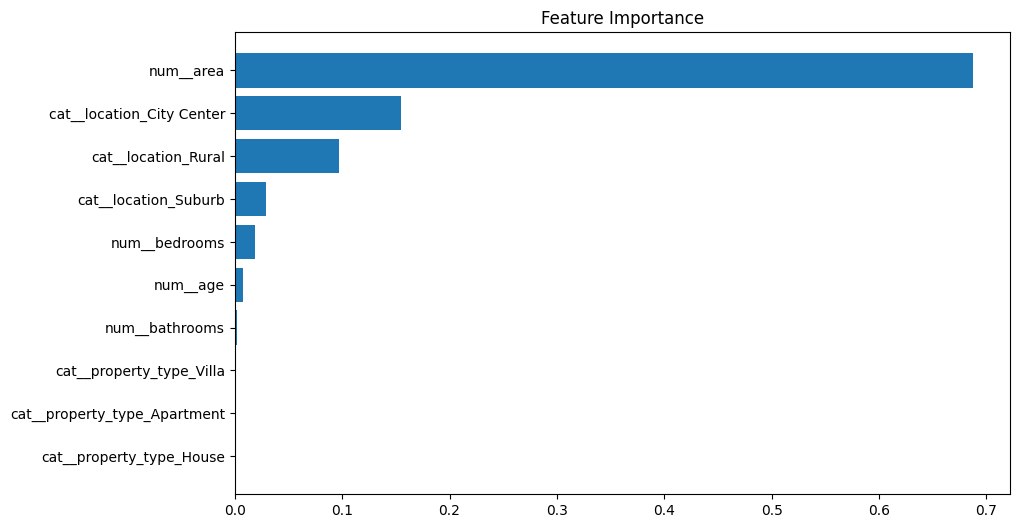

In [ ]:
import matplotlib.pyplot as plt

model = best_model.named_steps['model']

if hasattr(model, "feature_importances_"):
    feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
    importances = model.feature_importances_

    sorted_idx = np.argsort(importances)

    plt.figure(figsize=(10,6))
    plt.barh(feature_names[sorted_idx], importances[sorted_idx])
    plt.title("Feature Importance")
    plt.show()